Dataset Loaded
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9630 - loss: 0.1228 - val_accuracy: 0.9857 - val_loss: 0.0415
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9873 - loss: 0.0412 - val_accuracy: 0.9898 - val_loss: 0.0314
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.9911 - val_loss: 0.0270
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9928 - loss: 0.0212 - val_accuracy: 0.9902 - val_loss: 0.0298
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9949 - loss: 0.0149 - val_accuracy: 0.9925 - val_loss: 0.0275
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0275

Test Accuracy: 0.9925000071525574
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

Predicted: 7
Actual: 7


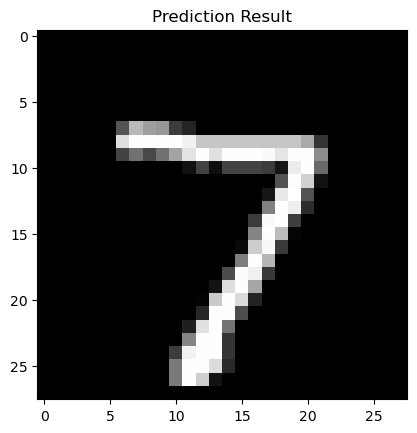

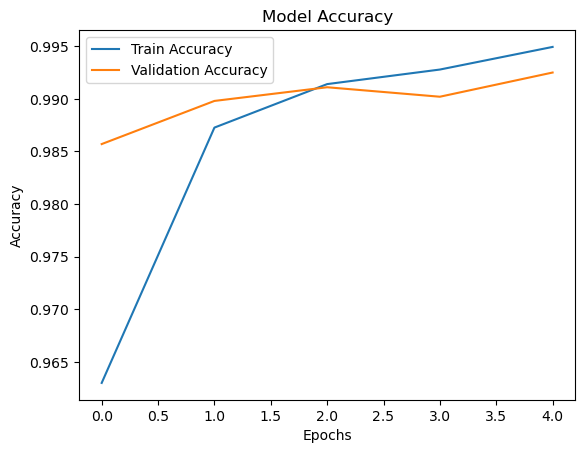


Model saved successfully!


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from tensorflow.keras.models import Sequential

# 1. Load data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Dataset Loaded")
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# 2. Preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)   # shape -> (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, -1)

# 3. Build model (Input layer used correctly, no warning)
model = Sequential([
    Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# 4. Train
history = model.fit(x_train, y_train,
                     epochs=5,
                     validation_data=(x_test, y_test))

# 5. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

# 6. Predict a single sample
index = 0
sample = np.expand_dims(x_test[index], axis=0)
prediction = model.predict(sample)
predicted_label = np.argmax(prediction)

print("\nPredicted:", predicted_label)
print("Actual:", y_test[index])

plt.figure()
plt.title("Prediction Result")
plt.imshow(x_test[index].reshape(28, 28), cmap="gray")
plt.show()

# 7. Plot accuracy
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 8. Save model in native Keras format (no legacy warning)
model.save("handwritten_model.keras")
print("\nModel saved successfully!")